# QAT bePC with quantized errors (W/A/E)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thebuckleylab/jpc/blob/main/examples/qat_bepc_errors.ipynb)

This notebook extends [`qat_bepc.ipynb`](./qat_bepc.ipynb) by also quantizing the **prediction errors** of the bidirectional error-reparameterised PC variant ([bePC](./bepc.ipynb)), which combines the bidirectional PC architecture ([Oliviers et al., 2025](https://arxiv.org/abs/2505.23415)) with the error reparameterisation of [ePC](https://arxiv.org/abs/2505.20137) ([Goemaere et al., 2025](https://arxiv.org/abs/2505.20137)).

Standard ANN quantization touches two things: **weights (W)** and **activations (A)**. [`qat_bepc.ipynb`](./qat_bepc.ipynb) does exactly that — `QuantLinear` fake-quantizes the weights and input activations of every layer in both the top-down generator and the bottom-up amortiser. But a PCN has a third first-class signal that an ANN does not: the **errors (E)**. In the error-reparameterised formulation the errors $\epsilon_\ell$ *are* the inference state — they are relaxed during the E-step and they drive every parameter update through the perturbed activities $\tilde{z}_\ell = f_\ell(\tilde{z}_{\ell-1}) + \epsilon_\ell$. Leaving them in float32 while quantizing W and A is arguably an oversight: on real low-precision hardware the error registers would be quantized just like everything else.

So here we add a third quantization axis, **E**, and report ablations over it. The naming convention `W4A8E8` means 4-bit weights, 8-bit activations, 8-bit errors. We do not sweep all permutations — the two headline configurations are:

- **W4A8E8**: 4-bit weights, 8-bit activations, 8-bit errors.
- **W4A4E4**: 4-bit weights, 4-bit activations, 4-bit errors.

plus an **error-precision ablation** that holds W and A fixed and sweeps E ∈ {float32, 8-bit, 4-bit}, isolating exactly what quantizing the error state costs. Passing `e_format=None` (float32 errors) recovers the behaviour of [`qat_bepc.ipynb`](./qat_bepc.ipynb), so that notebook is the E-unquantized baseline for everything below.

The W/A recipe is unchanged from [`qat_bepc.ipynb`](./qat_bepc.ipynb): **fake quantization** with a **straight-through estimator (STE)** on the weights and input activations of every `QuantLinear`, applied to both the top-down generator and the bottom-up amortiser. What is new is `quantize_errors`, which snaps the bePC error state to a chosen grid after every relaxation step.

Two number formats, as before:
- **Posit** (primary): Posit\<4,2\> for weights and Posit\<8,2\> for 8-bit activations/errors, mirroring the `Posit4.jl` LUT-based reference and the `softposit` Python package for 8-bit.
- **FP** (ablation): FP4 `E2M1` (MXFP4-style) and FP8 `E4M3`.

In [ ]:
%%capture
!pip install torch==2.3.1
!pip install torchvision==0.18.1
!pip install matplotlib==3.0.0

In [1]:
import math
from typing import Optional

import jpc

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import equinox.nn as nn
import optax

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')

## Hyperparameters

Matching [`bepc.ipynb`](./bepc.ipynb): a shallow joint generator/classifier where $x$ is the one-hot label (`INPUT_DIM=10`) and $y$ is the flattened image (`OUTPUT_DIM=784`).

In [2]:
SEED = 0

INPUT_DIM = 10
WIDTH = 256
DEPTH = 2
OUTPUT_DIM = 784
ACT_FN = "relu"

ERROR_LR = 5e-1
PARAM_LR = 1e-3
BATCH_SIZE = 64
TEST_EVERY = 50
N_TRAIN_ITERS = 300

## Quantization grids

Each format is defined by a sorted 1D array of its representable finite values. At forward time, a tensor is quantized by:

1. computing a per-tensor **absmax scale** so the largest magnitude maps to the largest representable level,
2. snapping every scaled element to the **nearest level**,
3. rescaling back.

Special encodings (NaR for posits, NaN for FP) are dropped from the grid — they should never appear in a well-scaled tensor and would break nearest-neighbour search.

In [3]:
def enumerate_posit(n: int, es: int) -> np.ndarray:
    """All finite values representable by Posit<n,es>, sorted, NaR excluded.

    Matches the Posit<4,es> tables in ``Posit4.jl`` (useed = 2**(2**es)).
    """
    useed = 2 ** (2 ** es)
    nar = 1 << (n - 1)
    mask = (1 << n) - 1
    out = set()
    for bits in range(1 << n):
        if bits == nar:
            continue
        if bits == 0:
            out.add(0.0); continue
        s = (bits >> (n - 1)) & 1
        mag = bits if s == 0 else ((~bits) + 1) & mask
        rb = mag & ((1 << (n - 1)) - 1)
        pos = n - 2
        r_sign = (rb >> pos) & 1
        m = 0
        while pos >= 0 and ((rb >> pos) & 1) == r_sign:
            m += 1; pos -= 1
        k = (m - 1) if r_sign == 1 else -m
        if pos >= 0:
            pos -= 1  # terminating bit
        exp_avail = min(es, pos + 1)
        if exp_avail > 0:
            e = (rb >> (pos - exp_avail + 1)) & ((1 << exp_avail) - 1)
            pos -= exp_avail
        else:
            e = 0
        fb = pos + 1
        f = ((rb & ((1 << fb) - 1)) / (1 << fb)) if fb > 0 else 0.0
        v = (useed ** k) * (2 ** e) * (1 + f)
        out.add(-v if s else v)
    return np.array(sorted(out), dtype=np.float32)


def enumerate_fp(ebits: int, mbits: int, bias: int, has_nan: bool = True) -> np.ndarray:
    """All finite values of an IEEE-style minifloat, sorted, NaN/Inf excluded.

    ``has_nan=True`` mirrors FP8 E4M3 (no Inf; NaN at Emax, mantissa=all-ones).
    ``has_nan=False`` mirrors MXFP4 E2M1, where every codepoint is a finite number.
    """
    total = 1 + ebits + mbits
    emax = (1 << ebits) - 1
    mmax = (1 << mbits) - 1
    out = set()
    for bits in range(1 << total):
        s = (bits >> (total - 1)) & 1
        e = (bits >> mbits) & emax
        m = bits & mmax
        if e == 0:
            v = (m / (1 << mbits)) * (2 ** (1 - bias))
        elif has_nan and e == emax and m == mmax:
            continue  # NaN slot
        else:
            v = (1 + m / (1 << mbits)) * (2 ** (e - bias))
        out.add(-v if s else v)
    return np.array(sorted(out), dtype=np.float32)


# Precomputed level grids. Kept as JAX arrays for fast nearest-neighbour search.
LEVELS = {
    "posit4_0":  jnp.asarray(enumerate_posit(4, 0)),
    "posit4_1":  jnp.asarray(enumerate_posit(4, 1)),
    "posit4_2":  jnp.asarray(enumerate_posit(4, 2)),
    "posit8_2":  jnp.asarray(enumerate_posit(8, 2)),
    "fp4_e2m1":  jnp.asarray(enumerate_fp(ebits=2, mbits=1, bias=1, has_nan=False)),
    "fp8_e4m3":  jnp.asarray(enumerate_fp(ebits=4, mbits=3, bias=7, has_nan=True)),
}

for name, lv in LEVELS.items():
    pos = lv[lv > 0]
    print(f"{name:10s}  {lv.size:3d} levels   "
          f"min|x|={float(pos.min()):.4g}   max|x|={float(pos.max()):.4g}")

posit4_0     15 levels   min|x|=0.25   max|x|=4
posit4_1     15 levels   min|x|=0.0625   max|x|=16
posit4_2     15 levels   min|x|=0.003906   max|x|=256
posit8_2    255 levels   min|x|=5.96e-08   max|x|=1.678e+07
fp4_e2m1     15 levels   min|x|=0.5   max|x|=6
fp8_e4m3    253 levels   min|x|=0.001953   max|x|=448


## Fake quantization, `QuantLinear`, and error quantization

`fake_quant` does per-tensor RMS scaling, nearest-level rounding, rescaling, and wraps the result in a **straight-through estimator** (`x + stop_gradient(x_q - x)`). We use RMS rather than absmax because posit precision peaks at $|x|=1$ — absmax scaling would squash typical values into the posit tails and waste most of the grid.

`QuantLinear` is a drop-in replacement for `eqx.nn.Linear` that quantizes its input activations with the chosen `a_format` and its weights with the chosen `w_format`. Because `QuantLinear` subclasses `eqx.nn.Linear`, it exposes a `.weight` attribute — matching what JPC's internals inspect when computing PC energies and gradients. This covers the **W** and **A** axes.

`quantize_errors` adds the **E** axis. It maps `fake_quant` over the bePC error PyTree, snapping every error tensor to the `e_format` grid with the same per-tensor RMS scaling. The bePC errors are relaxed by `jpc.update_bepc_errors`; in the training loop we round the returned error state with `quantize_errors` after *every* relaxation step, so each subsequent energy evaluation — and the final `jpc.update_bepc_params` update — sees E-format errors. The error state is therefore held in low precision throughout inference, exactly as weights and activations are. Passing `e_format=None` skips this and keeps errors in float32 (the [`qat_bepc.ipynb`](./qat_bepc.ipynb) baseline).

In [4]:
def fake_quant(x: jax.Array, levels: jax.Array) -> jax.Array:
    """Quantize ``x`` to the grid ``levels`` with RMS scaling + STE.

    - Per-tensor scale = RMS(x) so typical magnitudes map to |x|~1, where both
      posit and FP grids have their densest precision.
    - Nearest-neighbour rounding against the grid.
    - Straight-through gradient: ``grad(x_q) == grad(x)``.
    """
    scale = jnp.sqrt(jnp.mean(x * x) + 1e-12)
    x_scaled = x / scale
    diffs = jnp.abs(x_scaled[..., None] - levels)
    idx = jnp.argmin(diffs, axis=-1)
    x_q = levels[idx] * scale
    return x + jax.lax.stop_gradient(x_q - x)


class QuantLinear(nn.Linear):
    """``eqx.nn.Linear`` with fake-quantized weights and input activations."""

    w_format: str = eqx.field(static=True)
    a_format: str = eqx.field(static=True)

    def __init__(
        self,
        in_features: int,
        out_features: int,
        *,
        use_bias: bool = True,
        key,
        w_format: str,
        a_format: str,
    ):
        super().__init__(in_features, out_features, use_bias=use_bias, key=key)
        self.w_format = w_format
        self.a_format = a_format

    def __call__(self, x, *, key=None):
        x_q = fake_quant(x, LEVELS[self.a_format])
        W_q = fake_quant(self.weight, LEVELS[self.w_format])
        y = W_q @ x_q
        if self.bias is not None:
            y = y + self.bias
        return y


def make_quant_mlp(
    key,
    input_dim: int,
    width: int,
    depth: int,
    output_dim: int,
    act_fn: str,
    w_format: str,
    a_format: str,
    use_bias: bool = True,
):
    """Mirror of ``jpc.make_mlp`` that uses ``QuantLinear`` instead of ``nn.Linear``."""
    subkeys = jr.split(key, depth)
    act_lookup = {"relu": jax.nn.relu, "tanh": jnp.tanh, "gelu": jax.nn.gelu}
    layers = []
    for i in range(depth):
        act = nn.Identity() if i == 0 else nn.Lambda(act_lookup[act_fn])
        _in = input_dim if i == 0 else width
        _out = output_dim if (i + 1) == depth else width
        linear = QuantLinear(
            _in, _out,
            use_bias=use_bias,
            key=subkeys[i],
            w_format=w_format,
            a_format=a_format,
        )
        layers.append(nn.Sequential([act, linear]))
    return layers


def quantize_errors(errors, e_format: str):
    """Snap every bePC error tensor to the ``e_format`` grid (the **E** axis).

    The bePC errors are the inference state of the network: in a fully
    quantized PCN they belong in low precision just like weights and
    activations. We map ``fake_quant`` (per-tensor RMS scaling + nearest-level
    rounding) over the error PyTree returned by ``jpc.update_bepc_errors``.
    Applied after each relaxation step, so the error state is held in
    ``e_format`` throughout inference.
    """
    levels = LEVELS[e_format]
    return jax.tree_util.tree_map(lambda e: fake_quant(e, levels), errors)

### Sanity check

Round-trip a random tensor through each format to confirm the quantizer snaps to the grid and that the STE leaves gradients untouched, then round-trip a list of error-shaped tensors through `quantize_errors` to confirm the **E** axis snaps each leaf of the error PyTree.

In [5]:
_rng = jr.PRNGKey(0)
_x = jr.normal(_rng, (1024,))
for fmt in LEVELS:
    _xq = fake_quant(_x, LEVELS[fmt])
    _err = float(jnp.sqrt(jnp.mean((_xq - _x) ** 2)))
    print(f"{fmt:10s}  RMSE(x, fake_quant(x)) = {_err:.4f}")

# STE check: gradient of a quantized identity should be 1.
_g = jax.grad(lambda x: fake_quant(x, LEVELS["posit4_2"]).sum())(_x)
print(f"STE grad mean = {float(_g.mean()):.6f}   (expected 1.0)")

# E-axis check: quantize_errors snaps every leaf of an error-shaped PyTree.
_errs = [jr.normal(jr.PRNGKey(i), (BATCH_SIZE, d))
         for i, d in enumerate((WIDTH, OUTPUT_DIM))]
_errs_q = quantize_errors(_errs, "posit8_2")
for i, (_e, _eq) in enumerate(zip(_errs, _errs_q)):
    _err = float(jnp.sqrt(jnp.mean((_eq - _e) ** 2)))
    print(f"error leaf[{i}]  shape={_e.shape}  RMSE(e, quantize_errors(e)) = {_err:.4f}")

posit4_0    RMSE(x, fake_quant(x)) = 0.1300
posit4_1    RMSE(x, fake_quant(x)) = 0.1929
posit4_2    RMSE(x, fake_quant(x)) = 0.2657
posit8_2    RMSE(x, fake_quant(x)) = 0.0260
fp4_e2m1    RMSE(x, fake_quant(x)) = 0.1509
fp8_e4m3    RMSE(x, fake_quant(x)) = 0.0260
STE grad mean = 1.000000   (expected 1.0)
error leaf[0]  shape=(64, 256)  RMSE(e, quantize_errors(e)) = 0.0265
error leaf[1]  shape=(64, 784)  RMSE(e, quantize_errors(e)) = 0.0265


## Dataset

Standard MNIST loader, identical to [`bepc.ipynb`](./bepc.ipynb).

In [6]:
def get_mnist_loaders(batch_size):
    train_data = MNIST(train=True, normalise=True)
    test_data = MNIST(train=False, normalise=True)
    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    test_loader = DataLoader(
        dataset=test_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    return train_loader, test_loader


class MNIST(datasets.MNIST):
    def __init__(self, train, normalise=True, save_dir="data"):
        if normalise:
            transform = transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.Normalize(
                        mean=(0.1307,), std=(0.3081,)
                    )
                ]
            )
        else:
            transform = transforms.Compose([transforms.ToTensor()])
        super().__init__(save_dir, download=True, train=train, transform=transform)

    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        return torch.flatten(img), one_hot(label)


def one_hot(labels, n_classes=10):
    return torch.eye(n_classes)[labels]


def plot_mnist_imgs(imgs, labels, n_imgs=10):
    plt.figure(figsize=(20, 2))
    for i in range(n_imgs):
        plt.subplot(1, n_imgs, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(imgs[i].reshape(28, 28), cmap=plt.cm.binary_r)
        plt.xlabel(jnp.argmax(labels, axis=1)[i])
    plt.show()

## Train and test

The training loop is the standard bePC recipe from [`bepc.ipynb`](./bepc.ipynb): initialize zero errors, relax them for `depth - 1` steps with `jpc.update_bepc_errors`, then make a single joint update of the generator and amortiser with `jpc.update_bepc_params`. Two changes from [`bepc.ipynb`](./bepc.ipynb):

1. Both networks are built by `make_quant_mlp` rather than `jpc.make_mlp` — every matmul in the bidirectional forward/backward energies is fake-quantized (the **W** and **A** axes).
2. After each `jpc.update_bepc_errors` step the relaxed errors are passed through `quantize_errors` (the **E** axis), unless `e_format=None`. The quantized error state is what the next relaxation step and the final parameter update consume.

The STE in `fake_quant` lets the bePC error and parameter gradients flow through the quantizer as if it were the identity, so every JPC update function works unchanged. Note that the error quantization happens *between* `jpc.update_bepc_errors` calls — we round the returned error state rather than reaching inside the energy — so no STE is needed for it (see the notes at the end).

In [7]:
def evaluate(generator, amortiser, test_loader):
    amort_accs = 0.
    for _, (img_batch, label_batch) in enumerate(test_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_accs += jpc.compute_accuracy(label_batch, preds)

    img_preds = jpc.init_activities_with_ffwd(
        model=generator,
        input=label_batch
    )[-1]

    return (
        amort_accs / len(test_loader),
        label_batch,
        img_preds
    )


def train(
    seed,
    input_dim,
    width,
    depth,
    output_dim,
    act_fn,
    batch_size,
    error_lr,
    param_lr,
    test_every,
    n_train_iters,
    w_format: str,
    a_format: str,
    e_format: Optional[str] = None,
    forward_energy_weight: float = 1.0,
    show_samples: bool = False,
):
    key = jax.random.PRNGKey(seed)
    gen_key, amort_key = jax.random.split(key, 2)

    # models (NOTE: input and output are inverted for the amortiser)
    generator = make_quant_mlp(
        gen_key,
        input_dim=input_dim,
        width=width,
        depth=depth,
        output_dim=output_dim,
        act_fn=act_fn,
        w_format=w_format,
        a_format=a_format,
        use_bias=True,
    )
    amortiser = make_quant_mlp(
        amort_key,
        input_dim=output_dim,
        width=width,
        depth=depth,
        output_dim=input_dim,
        act_fn=act_fn,
        w_format=w_format,
        a_format=a_format,
        use_bias=True,
    )[::-1]

    # optimisers
    error_optim = optax.sgd(error_lr)
    gen_optim = optax.adam(param_lr)
    amort_optim = optax.adam(param_lr)
    gen_opt_state = gen_optim.init(eqx.filter(generator, eqx.is_array))
    amort_opt_state = amort_optim.init(eqx.filter(amortiser, eqx.is_array))

    layer_sizes = [input_dim] + [width] * (depth - 1) + [output_dim]

    # data
    train_loader, test_loader = get_mnist_loaders(batch_size)

    for it, (img_batch, label_batch) in enumerate(train_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        # feedforward losses (for logging only)
        amort_preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_loss = jpc.mse_loss(amort_preds, label_batch)

        gen_preds = jpc.init_activities_with_ffwd(
            model=generator,
            input=label_batch
        )[-1]
        gen_loss = jpc.mse_loss(gen_preds, img_batch)

        # bePC: initialise errors to zero and run inference on them
        errors = jpc.init_epc_errors(
            layer_sizes=layer_sizes,
            batch_size=batch_size
        )
        error_opt_state = error_optim.init(errors)

        for _ in range(depth - 1):
            error_update_result = jpc.update_bepc_errors(
                top_down_model=generator,
                bottom_up_model=amortiser,
                errors=errors,
                optim=error_optim,
                opt_state=error_opt_state,
                output=img_batch,
                input=label_batch,
                forward_energy_weight=forward_energy_weight
            )
            errors = error_update_result["errors"]
            error_opt_state = error_update_result["opt_state"]

            # E axis: hold the relaxed error state in e_format. With e_format
            # None the errors stay float32, reproducing qat_bepc.ipynb.
            if e_format is not None:
                errors = quantize_errors(errors, e_format)

        # learning
        param_update_result = jpc.update_bepc_params(
            top_down_model=generator,
            bottom_up_model=amortiser,
            errors=errors,
            top_down_optim=gen_optim,
            bottom_up_optim=amort_optim,
            top_down_opt_state=gen_opt_state,
            bottom_up_opt_state=amort_opt_state,
            output=img_batch,
            input=label_batch,
            forward_energy_weight=forward_energy_weight
        )
        generator, amortiser = param_update_result["models"]
        gen_opt_state, amort_opt_state = param_update_result["opt_states"]

        if ((it + 1) % test_every) == 0:
            amort_acc, label_batch, img_preds = evaluate(
                generator, amortiser, test_loader
            )
            print(
                f"[W:{w_format} A:{a_format} E:{e_format or 'fp32'}] "
                f"iter {it + 1}, "
                f"gen loss={float(gen_loss):.4f}, "
                f"amort loss={float(amort_loss):.4f}, "
                f"amort test acc={float(amort_acc):.4f}"
            )

            if (it + 1) >= n_train_iters:
                break

    if show_samples:
        plot_mnist_imgs(img_preds, label_batch)

    return generator, amortiser

## Run — W4A8E8 posits (primary target)

4-bit **Posit\<4,2\>** weights, 8-bit **Posit\<8,2\>** activations, and 8-bit **Posit\<8,2\>** errors, applied to both the generator and the amortiser. The Posit\<4,2\> grid is the same as the one tabulated in the accompanying `Posit4.jl` reference. Relative to the W4A8 run in [`qat_bepc.ipynb`](./qat_bepc.ipynb), the only addition is that the relaxed bePC error state is now also held at 8-bit posit precision. We show generated samples from the quantized generator at the end of training.

[W:posit4_2 A:posit8_2 E:posit8_2] iter 50, gen loss=249.7273, amort loss=0.2873, amort test acc=74.3289
[W:posit4_2 A:posit8_2 E:posit8_2] iter 100, gen loss=229.2611, amort loss=0.2552, amort test acc=80.8994
[W:posit4_2 A:posit8_2 E:posit8_2] iter 150, gen loss=214.4293, amort loss=0.2685, amort test acc=80.5990
[W:posit4_2 A:posit8_2 E:posit8_2] iter 200, gen loss=221.6736, amort loss=0.2618, amort test acc=80.2083
[W:posit4_2 A:posit8_2 E:posit8_2] iter 250, gen loss=219.1887, amort loss=0.2629, amort test acc=80.6591
[W:posit4_2 A:posit8_2 E:posit8_2] iter 300, gen loss=211.5616, amort loss=0.2374, amort test acc=80.8093


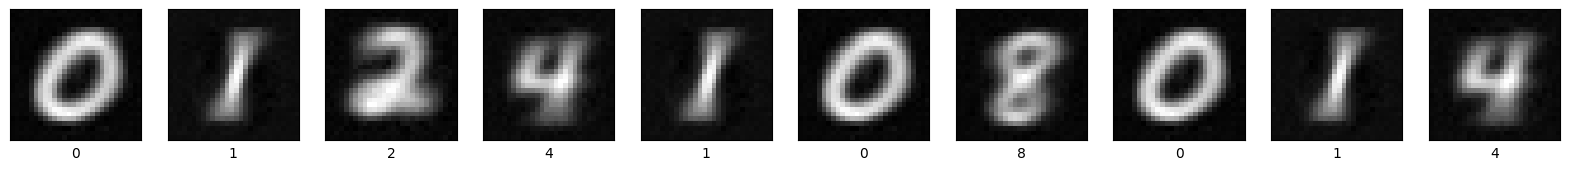

In [8]:
_ = train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    w_format="posit4_2",
    a_format="posit8_2",
    e_format="posit8_2",
    show_samples=True,
)

### Classification-biased run

As with bPC and bePC, downweighting the forward energy (equivalently upweighting the backward / classification energy) biases the joint objective toward classification. We reproduce this knob under the same W4A8E8 posit configuration with $\alpha_f = 10^{-3}$.

[W:posit4_2 A:posit8_2 E:posit8_2] iter 50, gen loss=276.5323, amort loss=0.2924, amort test acc=74.0184
[W:posit4_2 A:posit8_2 E:posit8_2] iter 100, gen loss=236.4838, amort loss=0.2806, amort test acc=75.5909
[W:posit4_2 A:posit8_2 E:posit8_2] iter 150, gen loss=231.4042, amort loss=0.2713, amort test acc=73.4876
[W:posit4_2 A:posit8_2 E:posit8_2] iter 200, gen loss=231.1400, amort loss=0.2735, amort test acc=73.9683
[W:posit4_2 A:posit8_2 E:posit8_2] iter 250, gen loss=243.9874, amort loss=0.2573, amort test acc=75.0901
[W:posit4_2 A:posit8_2 E:posit8_2] iter 300, gen loss=241.2044, amort loss=0.3264, amort test acc=72.2256


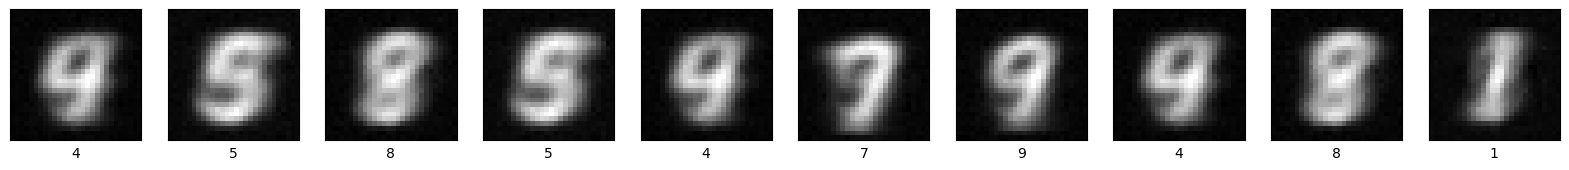

In [9]:
_ = train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    w_format="posit4_2",
    a_format="posit8_2",
    e_format="posit8_2",
    forward_energy_weight=1e-3,
    show_samples=True,
)

## Run — W4A4E4 posits

Pushing activations *and* errors down to Posit\<4,2\> as well. This is the most aggressive configuration — 4-bit weights, 4-bit activations, 4-bit errors — so expect a larger accuracy gap vs. the unquantized bePC baseline in [`bepc.ipynb`](./bepc.ipynb), and noticeably worse generative samples from the top-down network. The error-precision ablation below pins down how much of that gap is attributable to the 4-bit errors specifically.

[W:posit4_2 A:posit4_2 E:posit4_2] iter 50, gen loss=253.7770, amort loss=0.3508, amort test acc=61.7488
[W:posit4_2 A:posit4_2 E:posit4_2] iter 100, gen loss=242.0985, amort loss=0.3054, amort test acc=76.5925
[W:posit4_2 A:posit4_2 E:posit4_2] iter 150, gen loss=228.9905, amort loss=0.2838, amort test acc=77.5641
[W:posit4_2 A:posit4_2 E:posit4_2] iter 200, gen loss=246.0059, amort loss=0.3218, amort test acc=76.8129
[W:posit4_2 A:posit4_2 E:posit4_2] iter 250, gen loss=213.8010, amort loss=0.2669, amort test acc=76.7829
[W:posit4_2 A:posit4_2 E:posit4_2] iter 300, gen loss=228.4781, amort loss=0.3159, amort test acc=77.4740


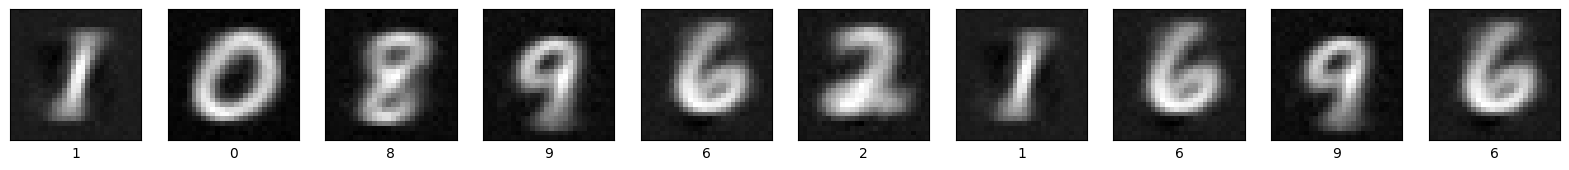

In [10]:
_ = train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    w_format="posit4_2",
    a_format="posit4_2",
    e_format="posit4_2",
    show_samples=True,
)

## Ablation — FP4/FP8

Swapping in MXFP4-style `E2M1` and `E4M3` FP8 grids across all three axes. Same training recipe, same number of mantissa+exponent bits per value; only the distribution of representable magnitudes differs. Running both W4A8E8 and W4A4E4 variants for direct comparison with the posit rows above — for FP, `E8` is FP8 `E4M3` and `E4` is FP4 `E2M1`.

[W:fp4_e2m1 A:fp8_e4m3 E:fp8_e4m3] iter 50, gen loss=242.3572, amort loss=0.2364, amort test acc=75.9515
[W:fp4_e2m1 A:fp8_e4m3 E:fp8_e4m3] iter 100, gen loss=224.8839, amort loss=0.2261, amort test acc=82.8025
[W:fp4_e2m1 A:fp8_e4m3 E:fp8_e4m3] iter 150, gen loss=201.4801, amort loss=0.1974, amort test acc=82.3117
[W:fp4_e2m1 A:fp8_e4m3 E:fp8_e4m3] iter 200, gen loss=231.9052, amort loss=0.2288, amort test acc=80.7392
[W:fp4_e2m1 A:fp8_e4m3 E:fp8_e4m3] iter 250, gen loss=218.2810, amort loss=0.2015, amort test acc=83.2732
[W:fp4_e2m1 A:fp8_e4m3 E:fp8_e4m3] iter 300, gen loss=223.1212, amort loss=0.2299, amort test acc=82.3718


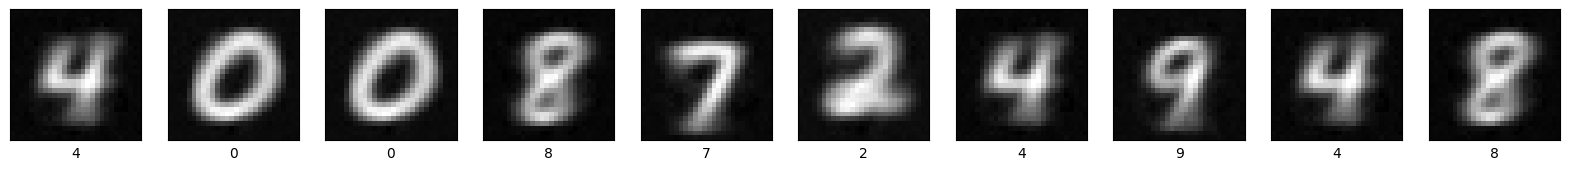

[W:fp4_e2m1 A:fp4_e2m1 E:fp4_e2m1] iter 50, gen loss=261.1870, amort loss=0.2849, amort test acc=74.4692
[W:fp4_e2m1 A:fp4_e2m1 E:fp4_e2m1] iter 100, gen loss=229.0916, amort loss=0.2493, amort test acc=81.0397
[W:fp4_e2m1 A:fp4_e2m1 E:fp4_e2m1] iter 150, gen loss=235.4629, amort loss=0.3036, amort test acc=80.8193
[W:fp4_e2m1 A:fp4_e2m1 E:fp4_e2m1] iter 200, gen loss=228.0966, amort loss=0.2551, amort test acc=82.5921
[W:fp4_e2m1 A:fp4_e2m1 E:fp4_e2m1] iter 250, gen loss=231.4530, amort loss=0.2563, amort test acc=83.1530
[W:fp4_e2m1 A:fp4_e2m1 E:fp4_e2m1] iter 300, gen loss=221.5576, amort loss=0.2510, amort test acc=81.3502


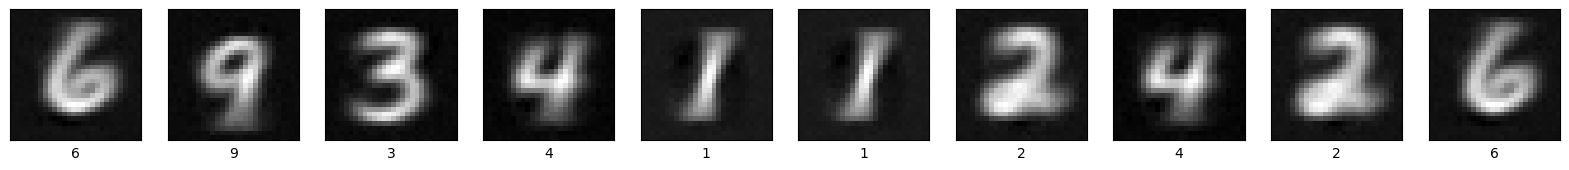

In [11]:
# W4A8E8 in FP: FP4 E2M1 weights, FP8 E4M3 activations and errors.
_ = train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    w_format="fp4_e2m1",
    a_format="fp8_e4m3",
    e_format="fp8_e4m3",
    show_samples=True,
)

# W4A4E4 in FP: FP4 E2M1 weights, activations, and errors.
_ = train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    w_format="fp4_e2m1",
    a_format="fp4_e2m1",
    e_format="fp4_e2m1",
    show_samples=True,
)

## Ablation — error precision (the E axis)

This is the ablation the notebook exists for. We hold the weight and activation formats fixed and sweep **only** the error format `E`, including `e_format=None` (float32 errors, i.e. the [`qat_bepc.ipynb`](./qat_bepc.ipynb) behaviour). Comparing the three E rows within each (W, A) block isolates the cost of quantizing the bePC error state from the cost of quantizing W and A.

Two (W, A) blocks, each swept over E ∈ {fp32, Posit\<8,2\>, Posit\<4,2\>}:
- **W4A8**: Posit\<4,2\> weights, Posit\<8,2\> activations.
- **W4A4**: Posit\<4,2\> weights and activations.

If the `fp32 → 8-bit` error step barely moves accuracy but `8-bit → 4-bit` does, that tells you the error state tolerates moderate quantization but degrades past a point — directly useful for choosing an error-register width on low-precision hardware. We skip the sample grids here (six runs) and read off the `amort test acc` lines instead.

In [12]:
# Hold (W, A) fixed, sweep only E. e_fmt=None keeps errors in float32.
for w_fmt, a_fmt in (("posit4_2", "posit8_2"), ("posit4_2", "posit4_2")):
    for e_fmt in (None, "posit8_2", "posit4_2"):
        _ = train(
            seed=SEED,
            input_dim=INPUT_DIM,
            width=WIDTH,
            depth=DEPTH,
            output_dim=OUTPUT_DIM,
            act_fn=ACT_FN,
            batch_size=BATCH_SIZE,
            error_lr=ERROR_LR,
            param_lr=PARAM_LR,
            test_every=TEST_EVERY,
            n_train_iters=N_TRAIN_ITERS,
            w_format=w_fmt,
            a_format=a_fmt,
            e_format=e_fmt,
            show_samples=False,
        )

[W:posit4_2 A:posit8_2 E:fp32] iter 50, gen loss=248.6248, amort loss=0.2760, amort test acc=74.5994
[W:posit4_2 A:posit8_2 E:fp32] iter 100, gen loss=235.7469, amort loss=0.3020, amort test acc=79.6174
[W:posit4_2 A:posit8_2 E:fp32] iter 150, gen loss=212.7711, amort loss=0.2180, amort test acc=80.4487
[W:posit4_2 A:posit8_2 E:fp32] iter 200, gen loss=229.0717, amort loss=0.2569, amort test acc=80.2584
[W:posit4_2 A:posit8_2 E:fp32] iter 250, gen loss=222.9064, amort loss=0.2423, amort test acc=81.8810
[W:posit4_2 A:posit8_2 E:fp32] iter 300, gen loss=216.6072, amort loss=0.2827, amort test acc=80.1583
[W:posit4_2 A:posit8_2 E:posit8_2] iter 50, gen loss=256.5571, amort loss=0.2806, amort test acc=75.4908
[W:posit4_2 A:posit8_2 E:posit8_2] iter 100, gen loss=223.3028, amort loss=0.2441, amort test acc=77.9547
[W:posit4_2 A:posit8_2 E:posit8_2] iter 150, gen loss=222.6250, amort loss=0.2240, amort test acc=80.3786
[W:posit4_2 A:posit8_2 E:posit8_2] iter 200, gen loss=223.7089, amort lo

## Notes and extensions

- **The three quantization axes.** `QuantLinear` covers **W** (weights) and **A** (activations); `quantize_errors` covers **E** (the bePC error state). All three use the same `fake_quant` primitive — per-tensor RMS scaling, nearest-level rounding, STE. With `e_format=None` this notebook reduces exactly to [`qat_bepc.ipynb`](./qat_bepc.ipynb), which is therefore the `E = float32` baseline.
- **Where the error quantization happens.** We round the error state *between* relaxation steps — after each `jpc.update_bepc_errors` call — rather than reaching inside the bePC energy. The quantizer is therefore never inside a single energy-gradient computation, so no STE is needed for it: the next error gradient is simply evaluated at the (already E-format) error state, exactly as activation quantization evaluates the next layer at `x_q`. This models errors being *stored and transmitted* in low precision.
- **A deeper E integration.** A stricter variant would fake-quantize the errors *inside* the bePC energy itself, with an STE, so the error-relaxation gradient sees the quantizer directly. That requires hooking into JPC's energy internals rather than post-processing the returned error PyTree, and is left as an extension.
- **Depth and the number of relaxation steps.** With `DEPTH=2` there is a single error-relaxation step per iteration, so the error state is quantized once before the parameter update. Deeper networks relax for more steps and the E quantization compounds across them — a natural place to expect the E axis to bite harder.
- **Master parameters stay float32.** As in [`qat_bepc.ipynb`](./qat_bepc.ipynb), only forward-pass matmuls and the error state see low precision; the generator/amortiser master weights remain float32 and the STE keeps their gradients intact.
- **Symmetric quantization of both networks.** The same `(w_format, a_format, e_format)` triple is used for the generator and amortiser. Asymmetric quantization — e.g. a high-precision amortiser paired with an aggressively quantized generator, or a coarser E grid on one side — is a natural next experiment.
- **Posit ES sweep.** The Posit\<4,`ES`\> weight-format sweep lives in [`qat_bepc.ipynb`](./qat_bepc.ipynb); it is orthogonal to the E axis and not repeated here. Re-running it with a quantized `e_format` is a straightforward combination of the two.
- **Swapping bePC for the incremental bidirectional variant.** The `make_quant_mlp` + `QuantLinear` + `quantize_errors` trio is independent of the PC algorithm. Pointing [`biepc.ipynb`](./biepc.ipynb) at them gives QAT biePC with quantized errors and no other changes.